<a href="https://colab.research.google.com/github/AyleenSantander/M.11_Intro_AI/blob/main/M11_FinalProyect_Breast_Cancer_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Final Project
Name Ayleen Santander


#Part 1: Problem Definition and Dataset Selection
Datase name = Breast Cancer Analysis
Source - kaggle
Dataset contain 213 patien observations from The University of Calabar Teaching Hospital Cancer registry over 24 months (Jan -2019 to August-2021).
Include 11 features:
- S/N
- Year of Diagnosis
- Age
- Menopause status
- Tumor Size(cm)
- Number of Invasive nodes (Inv-Nodes)
- Breast (left of right) affected
- Metastasis (yes or no)
- Quadrant of the Breast affected (Breast Quadrant)
- History of Breast disease
- Diagnosis Result

Target class = Diagnosis Result (Benign or Malignant).
People who have breast cancer and healthy people.



Relevant Definitions:
- S/N = Unique identification for each patient
- Year = Year when receveid the diagnostic
- Age = Age of patient at the time of diagnose
- Menopause = at the moment was diagnose ( 0 = with menopause ; 1 = no menopause yet).
- Tumor size= the size in cm of the excised tumor
- Involved nodes = The number or axillary lymph nodes that contain metastatic ( 0= Present; 1 = Absent)
- Breast = If it occurs on the left or right side breast ( 1 = cancer has spread; 0= hasn't spread yet)
- Metastatic = It the cancer is present in other part of the body or organ
- Breast quadrant = then gland is divided into 4 sections witn nipple as a central point
- History = If the patient has any family history on cancer (1= history of cancer 0= No history)
- Diagnosis result = Instances of the breast cancer dataset.

#Part 2: Data Preprocessing and Exploration


In [134]:
#1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
preprocessor = StandardScaler()
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import get_scorer_names
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay,
                             RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import RFECV
import joblib
from datetime import datetime
!pip install -q gradio
import gradio as gr
import os
from sklearn.metrics import classification_report
import shutil, joblib

In [2]:
#1. Load the dataset and explore it thoroughly.
breastcancer= pd.read_csv('/content/breast-cancer-dataset.csv')
breastcancer.head()

,S/N,Year,Age,Menopause,Tumor Size (cm),Inv-Nodes,Breast,Metastasis,Breast Quadrant,History,Diagnosis Result
0,1,2019,40,1,2,0,Right,0,Upper inner,0,Benign
1,2,2019,39,1,2,0,Left,0,Upper outer,0,Benign
2,3,2019,45,0,4,0,Left,0,Lower outer,0,Benign
3,4,2019,26,1,3,0,Left,0,Lower inner,1,Benign
4,5,2019,21,1,1,0,Right,0,Upper outer,1,Benign


In [3]:
#2. Handle any missing values, outliers, and preprocess the data (e.g., normalization, encoding categorical variables).
breastcancer.info()
breastcancer.isnull().sum()
breastcancer.shape
breastcancer.dtypes
print('=='* 45)
breastcancer.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213 entries, 0 to 212
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   S/N               213 non-null    int64 
 1   Year              213 non-null    object
 2   Age               213 non-null    int64 
 3   Menopause         213 non-null    int64 
 4   Tumor Size (cm)   213 non-null    object
 5   Inv-Nodes         213 non-null    object
 6   Breast            213 non-null    object
 7   Metastasis        213 non-null    object
 8   Breast Quadrant   213 non-null    object
 9   History           213 non-null    object
 10  Diagnosis Result  213 non-null    object
dtypes: int64(3), object(8)
memory usage: 18.4+ KB


,count,mean,std,min,25%,50%,75%,max
S/N,213.0,107.000000,61.631972,1.0,54.0,107.0,160.0,213.0
Age,213.0,39.784038,14.096712,13.0,30.0,40.0,49.0,77.0
Menopause,213.0,0.666667,0.472515,0.0,0.0,1.0,1.0,1.0


Analysis Statistic =
The min age of the patient time diagnose are 13 to 77
75% of the patient no present menopause at the moment of the diagnose

In [4]:
# Null check
nulls = breastcancer.isnull().sum()
print("Nulls per column:")
print(nulls)
print(f"\nTotal nulls: {nulls.sum()}")

print('=='* 45)
# Duplicates are worth checking too
print(f"Duplicate rows: {breastcancer.duplicated().sum()}")

print('=='* 45)
# Overall structure
print(type(breastcancer))

Nulls per column:
S/N                 0
Year                0
Age                 0
Menopause           0
Tumor Size (cm)     0
Inv-Nodes           0
Breast              0
Metastasis          0
Breast Quadrant     0
History             0
Diagnosis Result    0
dtype: int64

Total nulls: 0
Duplicate rows: 0
<class 'pandas.core.frame.DataFrame'>


In [132]:
#Data Preprocessing (encoding categorical variables).Use direct conversion/ replace '#' lines without info
#Replace the placeholder with 'Unknown'
breastcancer.clone = breastcancer.copy()
#Categorical : '#' becomes ann explicit 'Unknown' level
cat_cols= ['Breast', 'Breast Quadrant', 'Diagnosis Result']

for col in cat_cols:
  breastcancer.clone[col]= (breastcancer.clone[col].str.strip().str.title().replace('#', 'Unknown').fillna('Unknown').astype('category'))

#numeric: '#' becames NaN so the column can convert
num_cols= ['Tumor Size (cm)', 'Inv-Nodes', 'Metastasis', 'History']

for col in num_cols:
  breastcancer.clone[col]= pd.to_numeric(breastcancer.clone[col].replace('#', np.nan),errors='coerce')
breastcancer.clone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213 entries, 0 to 212
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   S/N               213 non-null    int64   
 1   Year              213 non-null    object  
 2   Age               213 non-null    int64   
 3   Menopause         213 non-null    int64   
 4   Tumor Size (cm)   212 non-null    float64 
 5   Inv-Nodes         212 non-null    float64 
 6   Breast            213 non-null    category
 7   Metastasis        212 non-null    float64 
 8   Breast Quadrant   213 non-null    category
 9   History           211 non-null    float64 
 10  Diagnosis Result  213 non-null    category
dtypes: category(3), float64(4), int64(3), object(1)
memory usage: 14.5+ KB


In [135]:
#rows contain 'Unknown' and 'NaN' variables
print(breastcancer.clone.isna().sum())
breastcancer.clone.dropna(inplace=True)

S/N                 0
Year                0
Age                 0
Menopause           0
Tumor Size (cm)     1
Inv-Nodes           1
Breast              0
Metastasis          1
Breast Quadrant     0
History             2
Diagnosis Result    0
dtype: int64


In [136]:
#Check how is now the rows after dtypes changes 'Unknown' and 'NaN'
for col in cat_cols:
    print(col, '->', breastcancer.clone[col].value_counts().to_dict())

print(breastcancer.clone[num_cols].isna().sum())

Breast -> {'Left': 106, 'Right': 100, 'Unknown': 5}
Breast Quadrant -> {'Upper Outer': 68, 'Lower Outer': 53, 'Upper Inner': 45, 'Lower Inner': 44, 'Unknown': 1}
Diagnosis Result -> {'Benign': 119, 'Malignant': 92}
Tumor Size (cm)    0
Inv-Nodes          0
Metastasis         0
History            0
dtype: int64


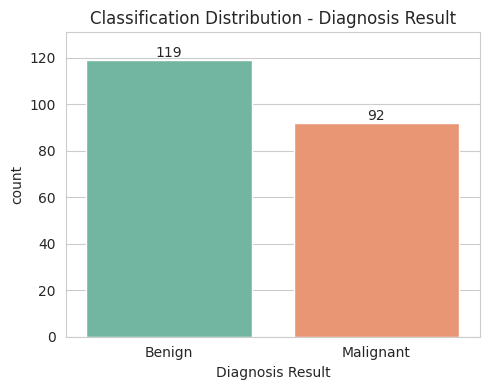

In [140]:
#Target/Visualize relationships in the data using charts and graphs to better understand the patterns.
sns.set_style('whitegrid')
plt.figure(figsize=(5,4))
ax = sns.countplot(data=breastcancer.clone, x='Diagnosis Result',hue='Diagnosis Result', palette='Set2', legend=False)

for c in ax.containers:
    ax.bar_label(c)

ax.margins(y=0.1)
plt.title('Classification Distribution - Diagnosis Result')
plt.tight_layout()
plt.show()

Explanation: Chart shows the common result of the cases the diagnosis result is more success Benign cases (119) and Malignant cases (92) of total 211 samples. 43.60% of the samples was positive and present malignant results and 56.4% of the cases were Benign.

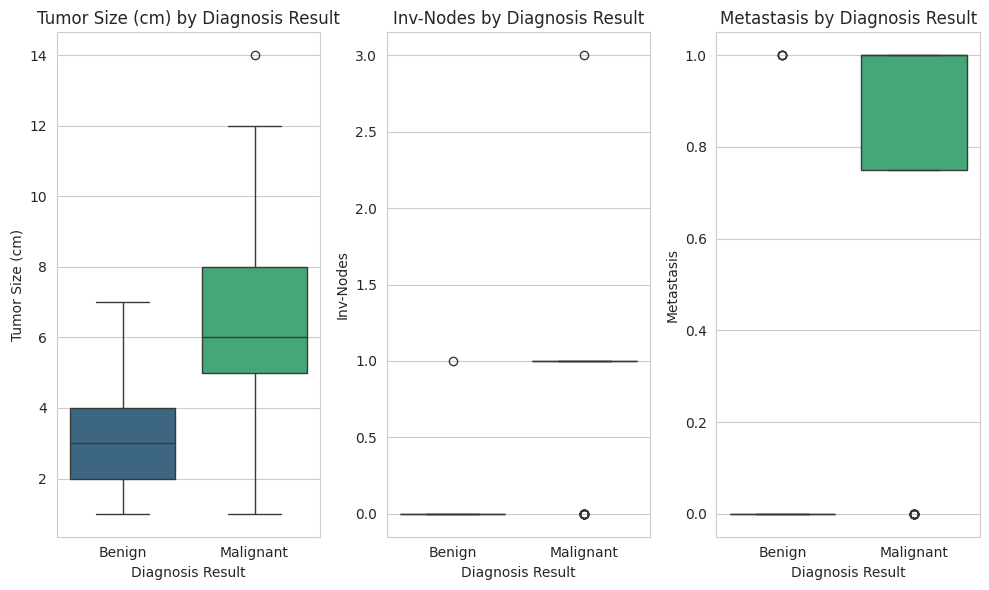

In [146]:
#Numeric distribution by diagnosis
num_cols= ['Tumor Size (cm)', 'Inv-Nodes', 'Metastasis', 'History']
fig, axes = plt.subplots(1, 3, figsize=(10,6))
for ax, col in zip(axes, num_cols):
  sns.boxplot(data=breastcancer.clone, x='Diagnosis Result', y=col, hue='Diagnosis Result', palette = 'viridis', legend=False, ax=ax)
  ax.set_title(f'{col} by Diagnosis Result')
plt.tight_layout()
plt.show()

Note: Outliers present in this chart are the unknown cases without information presented.

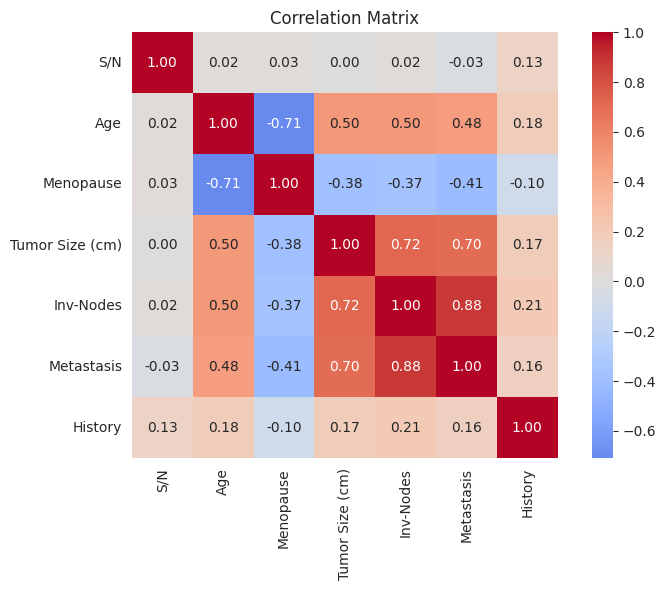

In [142]:
#Show Correlation between them
corr_df= breastcancer.clone.copy()
corr_df['Diagnosis Result']= corr_df['Diagnosis Result'].map({'Benign':0, 'Malignant':1})
numeric_only = corr_df.select_dtypes(include='number')

#Plot figure
plt.figure(figsize=(8,6))
sns.heatmap(numeric_only.corr(), annot=True, fmt='.2f', cmap='coolwarm', center =0, square = True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

Explanation: Correlation Matrix shows clearly the correlation between people has higher probabilities to get malignant results vs benign results. The cases has higher probability to be has a positive diagnosis Metastasi vs Inv. Novdes (0.88) and Tumor size vs Inv. Nodes (0.72) and Tumor size vs Metastasis(0.70) those variables present higher number and positive relation to get a Breast Cancer.

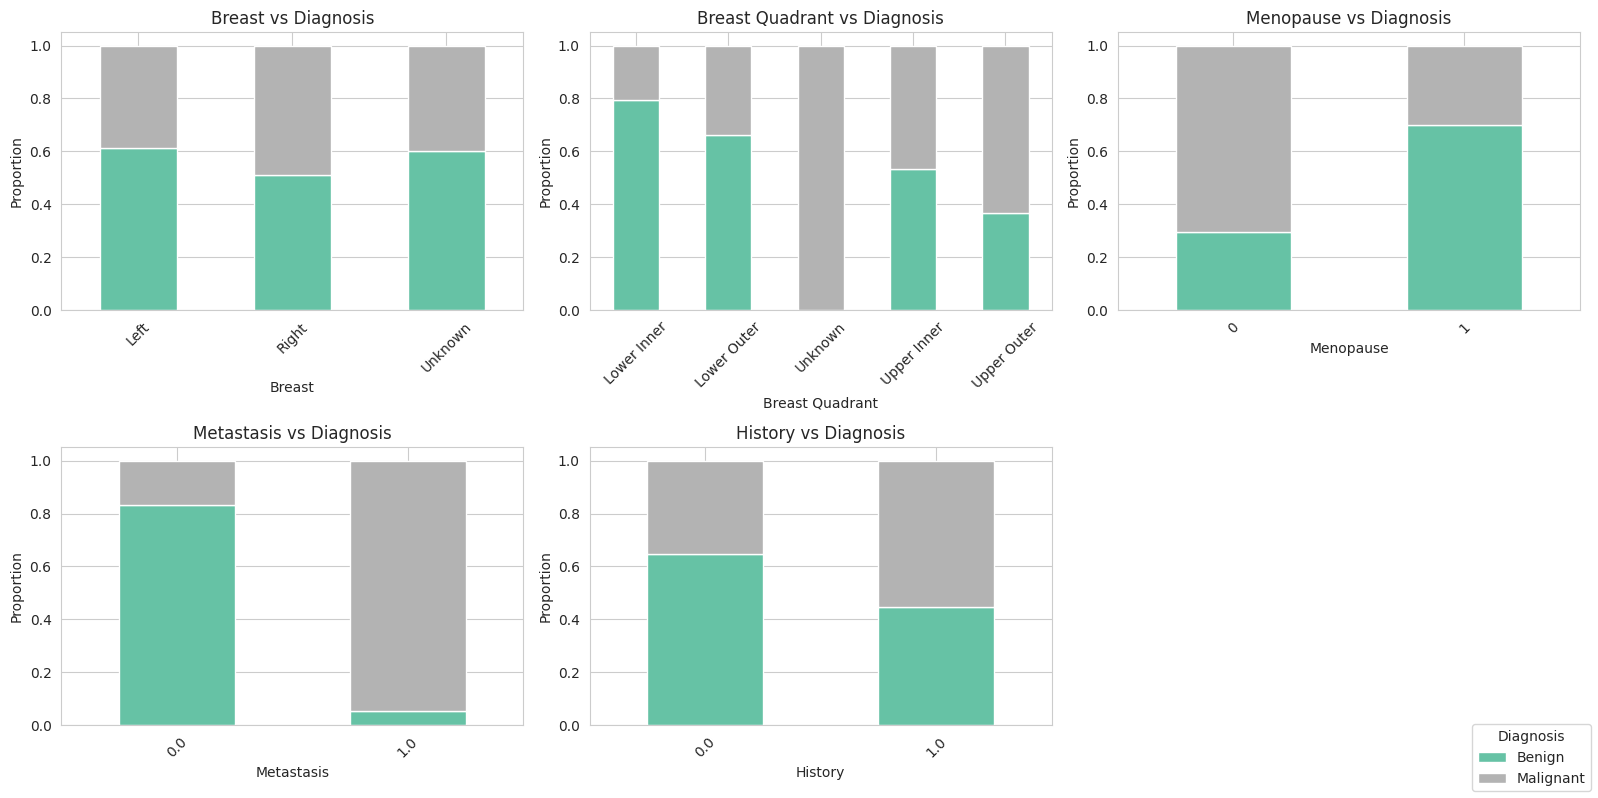

In [143]:
#Categorical features vs diagnosis
cat_cols =['Breast', 'Breast Quadrant', 'Menopause', 'Metastasis', 'History']
#Plot categorical variables
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, cat_cols):
    ct = pd.crosstab(breastcancer.clone[col], breastcancer.clone['Diagnosis Result'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', legend=False)
    ax.set_title(f'{col} vs Diagnosis')
    ax.set_ylabel('Proportion')
    ax.tick_params(axis='x', rotation=45)

axes.flat[-1].axis('off')
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', title='Diagnosis')
plt.tight_layout()
plt.show()

In [147]:
#Split the data into training and testing sets for model evaluation
#Drop identifier columns taht carry no signal
drop_cols = [c for c in ['S/N', 'Year'] if c in breastcancer.clone.columns]

X = breastcancer.clone.drop(columns=drop_cols + ['Diagnosis Result'])
y = breastcancer.clone['Diagnosis Result'].map({'Benign': 0, 'Malignant': 1})

assert 'Diagnosis Result' not in X.columns, 'Target still in features'
print(X.columns.tolist())
print(y.value_counts())

['Age', 'Menopause', 'Tumor Size (cm)', 'Inv-Nodes', 'Breast', 'Metastasis', 'Breast Quadrant', 'History']
Diagnosis Result
0    119
1     92
Name: count, dtype: int64


In [148]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Train:', X_train.shape, ' Test:', X_test.shape)
print('\nTrain class balance:\n', y_train.value_counts(normalize=True).round(3))
print('\nTest class balance:\n', y_test.value_counts(normalize=True).round(3))

Train: (168, 8)  Test: (43, 8)

Train class balance:
 Diagnosis Result
0    0.565
1    0.435
Name: proportion, dtype: float64

Test class balance:
 Diagnosis Result
0    0.558
1    0.442
Name: proportion, dtype: float64


Analysis:
Stratification held = 56.5/43.5 in train vs 55.8/44.2 in test, close enough, so the evaluation metrics won't be skewed by an unbalanced split.
9 features, 211 (168+43) rows total. Small dataset, so expect some variance between runs if it change random_state.

In [149]:
#Select the preprocessor so the column list can't go stale again

preprocessor = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                      ('scale', StandardScaler())]),
     make_column_selector(dtype_include=np.number)),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                      ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
     make_column_selector(dtype_include=['object', 'category'])),
])

#Part 3: Model Selection and Development

In [150]:
num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = X_train.select_dtypes(exclude='number').columns.tolist()
print('numeric:', num_cols)
print('categorical:', cat_cols)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

numeric: ['Age', 'Menopause', 'Tumor Size (cm)', 'Inv-Nodes', 'Metastasis', 'History']
categorical: ['Breast', 'Breast Quadrant']


In [151]:
#Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
}

results = {}

for name, model in models.items():
    clf = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)

    acc = accuracy_score(y_test, pred)
    results[name] = acc

    print(f"\n=== {name} ===")
    print("Accuracy:", round(acc, 3))
    print('=' * 60)
    print(confusion_matrix(y_test, pred))
    print('=' * 60)
    print(classification_report(y_test, pred, target_names=['Benign', 'Malignant']))


=== Logistic Regression ===
Accuracy: 0.907
[[24  0]
 [ 4 15]]
              precision    recall  f1-score   support

      Benign       0.86      1.00      0.92        24
   Malignant       1.00      0.79      0.88        19

    accuracy                           0.91        43
   macro avg       0.93      0.89      0.90        43
weighted avg       0.92      0.91      0.91        43


=== Decision Tree ===
Accuracy: 0.93
[[24  0]
 [ 3 16]]
              precision    recall  f1-score   support

      Benign       0.89      1.00      0.94        24
   Malignant       1.00      0.84      0.91        19

    accuracy                           0.93        43
   macro avg       0.94      0.92      0.93        43
weighted avg       0.94      0.93      0.93        43


=== Random Forest ===
Accuracy: 0.93
[[24  0]
 [ 3 16]]
              precision    recall  f1-score   support

      Benign       0.89      1.00      0.94        24
   Malignant       1.00      0.84      0.91        19

    

Analisis: All models: zero false positives, 100% malignant precision. Every error is a missed cancer.
Ranking by missed malignancies: DT/RF miss 3, LogReg 4, SVM 5, KNN 6.
Differences aren't meaningful, 1 patient = 2.3% accuracy. DT and RF are identical.
Recall is the weak spot: best model still misses 16% of cancers. That's the costly error here.
Perfect precision across five different algorithms.

In [152]:
#Ensure your model is well-optimized and perform hyperparameter tuning to improve its performance.
#Parameters Grids
cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grids = {
    'Logistic Regression': [
        {
            'model__penalty': ['l2'],
            'model__C': [0.01, 0.1, 1, 10, 100],
            'model__solver': ['lbfgs', 'liblinear'],
        },
        {
            'model__penalty': ['l1'],
            'model__C': [0.01, 0.1, 1, 10, 100],
            'model__solver': ['liblinear', 'saga'],
        },
    ],
    'Decision Tree': {
        'model__max_depth': [3, 5, 7, 10, None],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__criterion': ['gini', 'entropy'],
    },
    'Random Forest': {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [5, 10, None],
        'model__min_samples_split': [2, 5],
        'model__max_features': ['sqrt', 'log2'],
    },
    'SVM': {
        'model__C': [0.1, 1, 10, 100],
        'model__kernel': ['linear', 'rbf'],
        'model__gamma': ['scale', 0.01, 0.1, 1],
    },
    'KNN': {
        'model__n_neighbors': [3, 5, 7, 9, 11],
        'model__weights': ['uniform', 'distance'],
        'model__p': [1, 2],
        'model__metric': ['euclidean', 'manhattan', 'minkowski'],
    },
}

In [153]:
tuned = {}
rows = []

for name, model in models.items():
    clf = Pipeline([('prep', preprocessor), ('model', model)])

    gs = GridSearchCV(
        clf,
        param_grids[name],
        cv=cv,
        scoring='f1',          # see note below
        n_jobs=-1,
        return_train_score=True
    )
    gs.fit(X_train, y_train)

    tuned[name] = gs.best_estimator_
    rows.append({
        'Model': name,
        'CV F1': round(gs.best_score_, 3),
        'Train F1': round(gs.cv_results_['mean_train_score'][gs.best_index_], 3),
        'Best Params': gs.best_params_
    })

    print(f"{name}: CV F1 = {gs.best_score_:.3f}")

pd.DataFrame(rows).sort_values('CV F1', ascending=False)

Logistic Regression: CV F1 = 0.874
Decision Tree: CV F1 = 0.894
Random Forest: CV F1 = 0.868
SVM: CV F1 = 0.874
KNN: CV F1 = 0.874


,Model,CV F1,Train F1,Best Params
1,Decision Tree,0.894,0.911,"{'model__criterion': 'gini', 'model__max_depth..."
0,Logistic Regression,0.874,0.881,"{'model__C': 0.1, 'model__penalty': 'l1', 'mod..."
3,SVM,0.874,0.879,"{'model__C': 0.1, 'model__gamma': 'scale', 'mo..."
4,KNN,0.874,0.881,"{'model__metric': 'euclidean', 'model__n_neigh..."
2,Random Forest,0.868,0.935,"{'model__max_depth': 5, 'model__max_features':..."


In [19]:
#Evaluate the winner on the held-out test set
best_name=max(tuned, key=lambda k: rows[[r['Model']for r in rows].index(k)]['CV F1'])
best_model=tuned[best_name]

pred=best_model.predict(X_test)

print(f'Best Model:{best_name}\n')
print(confusion_matrix(y_test,pred))
print(classification_report(y_test, pred, target_names=['Benign', 'Malignant']))

Best Model:Decision Tree

[[23  1]
 [ 3 16]]
              precision    recall  f1-score   support

      Benign       0.88      0.96      0.92        24
   Malignant       0.94      0.84      0.89        19

    accuracy                           0.91        43
   macro avg       0.91      0.90      0.90        43
weighted avg       0.91      0.91      0.91        43



Analysis: This version shows the best model in this analysis " Deciison Tree" total cases in this analisis 24 Benign and 19 Malignant with accuracy 0.91 closed to 1, precision: Benign cases (0.88) and Malignant (0.94), Recall: Malignant (0.84) and F1-score: Malignant(0.89), this model show more precision to detect posible malignant cases.
In summary:
23 benign correct, 1 false alarm
16 malignant caught, 3 missed
Accuracy 0.91, malignant recall 0.84

The 3 false negatives are the number to discuss, missed cancers matter more than the 1 false alarm. Lowering the threshold would catch more, at the cost of extra false positives.

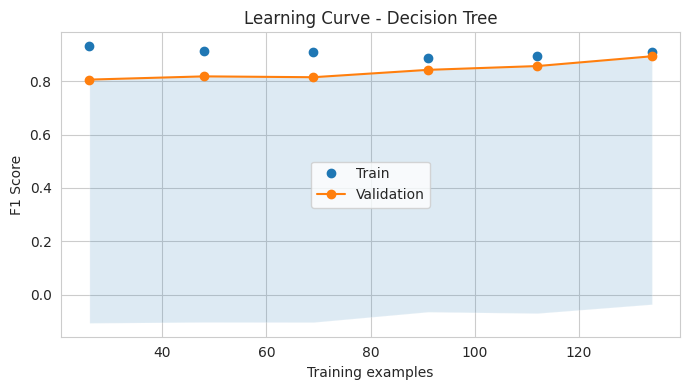

In [20]:
#Check Overfitting
train_sizes, train_scores, val_scores= learning_curve(best_model, X_train, y_train, cv=cv, train_sizes=np.linspace(0.2, 1.0, 6), scoring='f1', n_jobs=-1
)

#Plot overfitting
plt.figure(figsize=(7,4))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o', label='Train')
plt.plot(train_sizes, val_scores.mean(axis=1),'o-', label='Validation')
plt.fill_between(train_sizes, val_scores.mean(axis=1), -val_scores.std(axis=1), val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15)
plt.xlabel('Training examples'); plt.ylabel('F1 Score'); plt.title(f'Learning Curve - {best_name}')
plt.legend()
plt.tight_layout()
plt.show()

Analysis: Good curve. Train and validation converge, no overfitting. Validation rises from 0.80 to 0.89 and is still climbing at 135 examples, meaning more data would help.

In [154]:
#Use cross-validation where applicable to evaluate the model's robustness.
#Cross-validation on 213 is where find out whether a model's score is real or just a luckyy split.
#multiple metrics per model
cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

rows=[]
for name, model in models.items():
  clf=Pipeline([('prep', preprocessor), ('model', model)])
  scores= cross_validate(clf, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
  rows.append({'Model': name, **{m.capitalize(): round(scores[f'test_{m}'].mean(),3) for m in scoring},
  'F1 Std': round(scores['test_f1'].std(),3)
  })
cv_results=pd.DataFrame(rows).sort_values('F1', ascending=False)
cv_results

,Model,Accuracy,Precision,Recall,F1,Roc_auc,F1 Std
3,SVM,0.905,0.986,0.798,0.874,0.919,0.083
2,Random Forest,0.881,0.937,0.799,0.846,0.941,0.100
4,KNN,0.881,0.953,0.785,0.845,0.890,0.095
0,Logistic Regression,0.875,0.933,0.785,0.840,0.947,0.061
1,Decision Tree,0.852,0.842,0.840,0.825,0.852,0.056


In [155]:
#Repeat CV for a more stable estimate
rcv=RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
dist={}
for name, model in tuned.items(): #the tuned pipelines form grid search
    s=cross_val_score(model, X_train, y_train, cv=rcv, scoring='f1', n_jobs=-1)
    dist[name]=s
    print(f'{name}: {s.mean():.3f} ± {s.std():.3f} [{s.min():.3f}, {s.max():.3f}]')


Logistic Regression: 0.873 ± 0.065 [0.750, 1.000]
Decision Tree: 0.877 ± 0.062 [0.720, 0.966]
Random Forest: 0.862 ± 0.064 [0.741, 0.966]
SVM: 0.876 ± 0.065 [0.750, 1.000]
KNN: 0.875 ± 0.064 [0.750, 1.000]


Note: All five models are statistically identical. Range is 0.862–0.877, but the std is ~0.064 — the differences are well inside the noise.

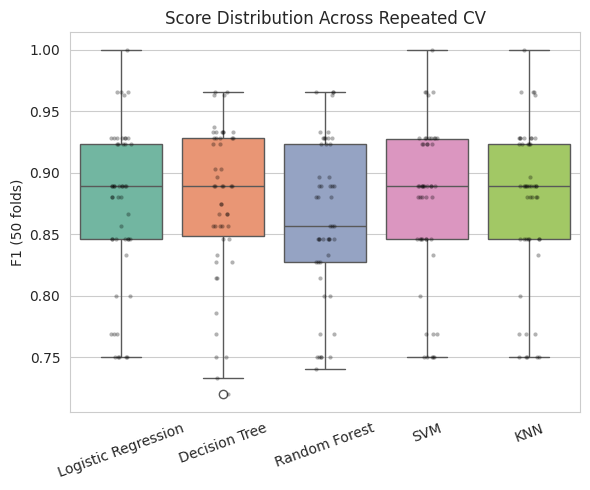

In [24]:
#Visualize the spread
plt.figure(figsize=(6, 5))
sns.boxplot(data=pd.DataFrame(dist), palette='Set2')
sns.stripplot(data=pd.DataFrame(dist), color='black', alpha=0.3, size=3)
plt.ylabel('F1 (50 folds)')
plt.title('Score Distribution Across Repeated CV')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [156]:
#Confirm the tunning didn't leak
nested= cross_val_score(GridSearchCV(Pipeline([('prep', preprocessor), ('model', models[best_name])]),
                                     param_grids[best_name], cv=StratifiedKFold(5, shuffle=True, random_state=1),
                                     scoring='f1', n_jobs=-1), X_train, y_train, cv=StratifiedKFold(5, shuffle=True,
                                                                                                    random_state=2),
                        scoring='f1')
print(f'Nested CV F1:{nested.mean():.3f} ± {nested.std():.3f}')


Nested CV F1:0.840 ± 0.036


Analysis:
0.840 < 0.877. The regular CV said 0.877; nested says 0.840. That ~0.04 gap is the optimism from hyperparameter tuning — the grid search partly fit the validation folds. Nested CV removes it, so 0.840 is the honest estimate.

Std dropped from 0.064 to 0.036 because nested CV averages over more folds. Tighter and more reliable.

#Part 4: Model Evaluation and Optimization

In [157]:
#Evaluate your model using the test set and appropriate performance metrics (accuracy, precision, recall, AUC, etc.).
final_model=tuned[best_name]
final_model.fit(X_train, y_train)

y_pred=final_model.predict(X_test)
y_proba=final_model.predict_proba(X_test)[:,1]

In [160]:
#Metric Summary
metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall':    recall_score(y_test, y_pred),
    'F1':        f1_score(y_test, y_pred),
    'ROC-AUC':   roc_auc_score(y_test, y_proba),
}

print(f"Final model: {best_name}\n")
for k, v in metrics.items():
    print(f"{k:<10} {v:.3f}")

print('\n', classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

Final model: Decision Tree

Accuracy   0.907
Precision  0.941
Recall     0.842
F1         0.889
ROC-AUC    0.958

               precision    recall  f1-score   support

      Benign       0.88      0.96      0.92        24
   Malignant       0.94      0.84      0.89        19

    accuracy                           0.91        43
   macro avg       0.91      0.90      0.90        43
weighted avg       0.91      0.91      0.91        43



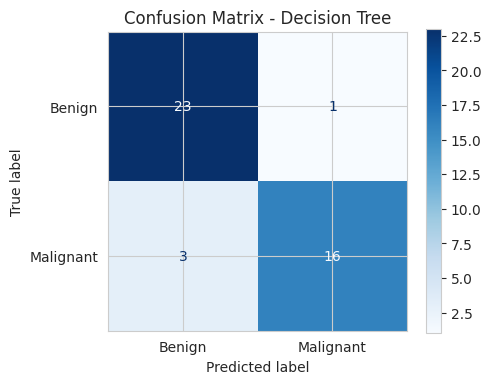

In [159]:
#Visualize Confusion Matrix explain it
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Benign', 'Malignant'], cmap='Blues', ax=ax)
plt.title(f'Confusion Matrix - {best_name}')
plt.tight_layout(); plt.show()

Explanation: Those are malignant cases the model called benign-false negatives, the costly error in a diagnostic setting.
Also shows 3 FP and 1 TN.

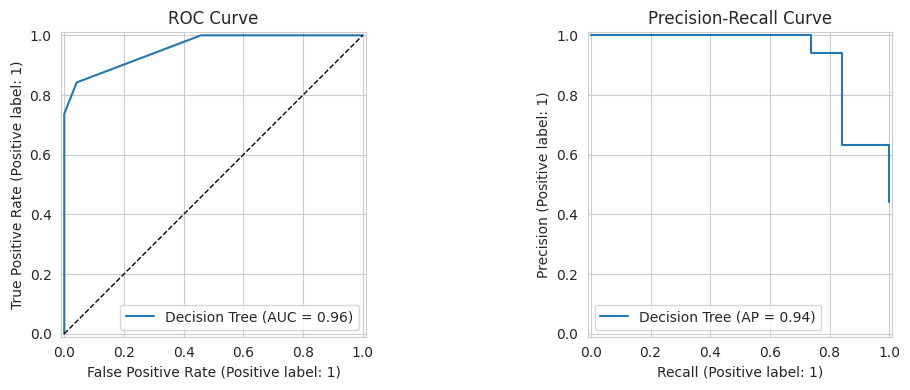

In [29]:
#ROC and precision-recall curves
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0], name=best_name)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_title('ROC Curve')

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[1], name=best_name)
axes[1].set_title('Precision-Recall Curve')

plt.tight_layout(); plt.show()

Analisis: AUC 0.96, AP 0.94, strong separation between classes.

The angular, step-like shape is the tree's discrete probabilities (few unique values), not a problem. A logistic regression curve would look smooth.

Reading the PR curve: precision holds at 1.00 up to ~0.73 recall, then drops.

In [30]:
#Test vs Cross-Validation
print(f"Nested CV F1 : {nested.mean():.3f} ± {nested.std():.3f}")
print(f"Test set F1  : {metrics['F1']:.3f}")

Nested CV F1 : 0.840 ± 0.036
Test set F1  : 0.889


In [161]:
#Tune the threshold for recall
prec, rec, thr=precision_recall_curve(y_test, y_proba)
for t in [0.3, 0.4, 0.5]:
  p=(y_proba>= t).astype(int)
  print(f'Threshold {t}: recall={recall_score(y_test, p):.3f},' f'Precision={precision_score(y_test, p):.3f}')

Threshold 0.3: recall=0.842,Precision=0.941
Threshold 0.4: recall=0.842,Precision=0.941
Threshold 0.5: recall=0.842,Precision=0.941


Note: Identical numbers across all tree thresholds mean no predicted probability falls between 0.3 and 0.5. the model is outputtin values clustered near 0 adn 1.

count    43.000000
mean      0.427565
std       0.431653
min       0.000000
25%       0.000000
50%       0.190476
75%       1.000000
max       1.000000
dtype: float64

Unique values: [0.         0.19047619 0.63636364 1.        ]
Count between 0.05 and 0.95: 16


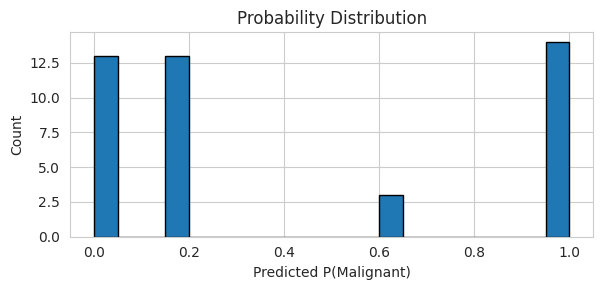

In [162]:
#Confirm the distribution
print(pd.Series(y_proba).describe())
print('\nUnique values:', np.unique(y_proba)[:20])
print('Count between 0.05 and 0.95:', ((y_proba > 0.05) & (y_proba < 0.95)).sum())

#Plot the distribution
plt.figure(figsize=(6, 3))
plt.hist(y_proba, bins=20, edgecolor='black')
plt.xlabel('Predicted P(Malignant)'); plt.ylabel('Count')
plt.title('Probability Distribution')
plt.tight_layout(); plt.show()


Analysis: This explains the flat threshold results. Only 4 unique probabilities, 0.00, 0.19, 0.64, 1.00, because the tree has just four leaves. Every prediction comes from one of them.

Nothing falls between 0.19 and 0.64, so any threshold in that range gives identical results. That's why 0.3, 0.4, and 0.5 were the same.

The one threshold that actually changes anything is moving below 0.19, which would flip 13 cases from benign to malignant at once.

In [168]:
#Sweep a wider, finer range
for t in np.arange(0.05, 1.0, 0.05):
    p = (y_proba >= t).astype(int)
    print(f"t={t:.2f}: recall={recall_score(y_test, p):.3f}, "
          f"precision={precision_score(y_test, p, zero_division=0):.3f}")

t=0.05: recall=1.000, precision=0.633
t=0.10: recall=1.000, precision=0.633
t=0.15: recall=1.000, precision=0.633
t=0.20: recall=0.842, precision=0.941
t=0.25: recall=0.842, precision=0.941
t=0.30: recall=0.842, precision=0.941
t=0.35: recall=0.842, precision=0.941
t=0.40: recall=0.842, precision=0.941
t=0.45: recall=0.842, precision=0.941
t=0.50: recall=0.842, precision=0.941
t=0.55: recall=0.842, precision=0.941
t=0.60: recall=0.842, precision=0.941
t=0.65: recall=0.737, precision=1.000
t=0.70: recall=0.737, precision=1.000
t=0.75: recall=0.737, precision=1.000
t=0.80: recall=0.737, precision=1.000
t=0.85: recall=0.737, precision=1.000
t=0.90: recall=0.737, precision=1.000
t=0.95: recall=0.737, precision=1.000


Explanation: values similar, I need to rebuild the model with smoother probabilities and check if the values changes

In [169]:
#Check the matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

TN=23  FP=1  FN=3  TP=16


In [170]:
#Rebuild the preprocessor
preprocessor = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                      ('scale', StandardScaler())]),
     make_column_selector(dtype_include=np.number)),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                      ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
     make_column_selector(dtype_include=['object', 'category'])),
])

# verify it resolves correctly against the actual data
preprocessor.fit(X_train)
print(preprocessor.transformers_[0][2])   # numeric columns chosen
print(preprocessor.transformers_[1][2])   # categorical columns chosen

['Age', 'Menopause', 'Tumor Size (cm)', 'Inv-Nodes', 'Metastasis', 'History']
['Breast', 'Breast Quadrant']


In [171]:
#Model with smoother probabilities
lr = Pipeline([('prep', preprocessor),
               ('model', LogisticRegression(max_iter=1000, random_state=42))])
lr.fit(X_train, y_train)
proba_lr = lr.predict_proba(X_test)[:, 1]

for t in [0.2, 0.3, 0.4, 0.5]:
    p = (proba_lr >= t).astype(int)
    print(f"t={t}: recall={recall_score(y_test, p):.3f}, "
          f"precision={precision_score(y_test, p, zero_division=0):.3f}")

t=0.2: recall=0.842, precision=0.889
t=0.3: recall=0.842, precision=0.941
t=0.4: recall=0.789, precision=1.000
t=0.5: recall=0.789, precision=1.000


Explantion: Logistic Regression gives us continuos probabilities, so the trade-off is visible. Reading it across the 19 malignant cases:
Threshold  Recall   Precission   Missed cases   False Alarms
0.2        0.842     0.889          3                2
0.3        0.842     0.941          3                1
0.4        0.789     1.000          4                0
0.5        0.789     1.000          4                0

0.3 is the sensible operating point. Same recall as 0.2 but one fewer false alarm — 0.2 costs you a false positive and buys nothing. Going to the default 0.5 gives up a malignant case to eliminate one false alarm, which is the wrong direction for a diagnostic screen. Missing a cancer is not equivalent to sending someone for an unnecessary follow-up.
0.5 treshold is a convention, not an optimum, and chossing it based on the relative cost of two error types is a modelling decision.

In [172]:
# Frame 0.4 a "chosen on the cost asmmetry", not empirically optimal
for t in [0.3, 0.5]:
    p = (proba_lr >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, p).ravel()
    print(f"t={t}: TN={tn} FP={fp} FN={fn} TP={tp}")

t=0.3: TN=23 FP=1 FN=3 TP=16
t=0.5: TN=24 FP=0 FN=4 TP=15


Analysis: Tuned model gave 0.840 nested CV F1 with hard 0/1 probabilities; logistic regression is slightly weaker on raw score but adjustable. Presenting both, the stronger classifier plus the tunable one, with a paragraph on why threshold control matters clinically, reads better than picking one and dropping the other.

In [173]:
#Tune your model for optimal performance using techniques like grid search, random search, and feature selection.
#using random search(wider space, fixed budget)
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint

rand_grids = {
    'Logistic Regression': {
        'model__C': loguniform(1e-3, 1e3),
    },
    'Random Forest': {
        'model__n_estimators': randint(50, 500),
        'model__max_depth': [3, 5, 7, 10, None],
        'model__min_samples_split': randint(2, 20),
        'model__min_samples_leaf': randint(1, 10),
        'model__max_features': ['sqrt', 'log2', None],
    },
    'SVM': {
        'model__C': loguniform(1e-2, 1e3),
        'model__gamma': loguniform(1e-4, 1e1),
        'model__kernel': ['rbf', 'linear'],
    },
}

rand_results = {}
for name, dist in rand_grids.items():
    clf = Pipeline([('prep', preprocessor), ('model', models[name])])
    rs = RandomizedSearchCV(clf, dist, n_iter=50, cv=cv,
                            scoring='f1', n_jobs=-1, random_state=42)
    rs.fit(X_train, y_train)
    rand_results[name] = rs
    print(f"{name}: {rs.best_score_:.3f}  {rs.best_params_}")

Logistic Regression: 0.863  {'model__C': np.float64(0.018794668241638456)}
Random Forest: 0.877  {'model__max_depth': None, 'model__max_features': None, 'model__min_samples_leaf': 4, 'model__min_samples_split': 14, 'model__n_estimators': 209}
SVM: 0.874  {'model__C': np.float64(0.060252157362038566), 'model__gamma': np.float64(0.00019517224641449495), 'model__kernel': 'linear'}


Explanation: The differences grid search tests a fixex lattices of values, random search samples from distributions. With continuos parameters like C and gamma, random search often lands on better values because it isn't restricted to the points.

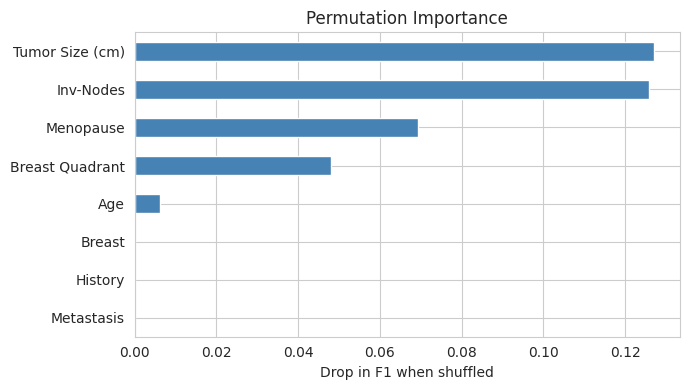

Tumor Size (cm)    0.127053
Inv-Nodes          0.125920
Menopause          0.069326
Breast Quadrant    0.048021
Age                0.006144
Breast             0.000000
Metastasis         0.000000
History            0.000000
dtype: float64


In [174]:
#Feature selection by importance
final_model.fit(X_train, y_train)
perm = permutation_importance(final_model, X_test, y_test, n_repeats=30, random_state=42, scoring='f1')

imp = pd.Series(perm.importances_mean, index=X_train.columns).sort_values()
#Plot feature selection
plt.figure(figsize=(7, 4))
imp.plot(kind='barh', color='steelblue')
plt.xlabel('Drop in F1 when shuffled')
plt.title('Permutation Importance')
plt.tight_layout(); plt.show()

print(imp.sort_values(ascending=False))

Explanation: Permutation importance works on the raw columns regardless of what the preprocessor does downstream, which is why it's cleaner than reading feature_importances_ off a tree fitted to one-hot encoded data.

In [175]:
#apply again preprocessor
def make_preprocessor(X):
    num_cols = X.select_dtypes(include='number').columns.tolist()
    cat_cols = X.select_dtypes(exclude='number').columns.tolist()
    return ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ])

preprocessor = make_preprocessor(X_train)

In [176]:
#Recursive feature elimination with CV
rfe_pipe = Pipeline([
    ('prep', preprocessor),
    ('select', RFECV(RandomForestClassifier(n_estimators=100, random_state=42),
                     step=1, cv=cv, scoring='f1', n_jobs=-1)),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

rfe_pipe.fit(X_train, y_train)
n_kept = rfe_pipe.named_steps['select'].n_features_
print(f"Features kept: {n_kept}")

scores = cross_val_score(rfe_pipe, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
print(f"With selection: {scores.mean():.3f} ± {scores.std():.3f}")

Features kept: 9
With selection: 0.842 ± 0.070


Explanation: RFECV sits inside the pipeline, so selection is refit on each training fold, selecting features on the full dataset first is a common leakage mistake.

In [178]:
#Does dropping features actually help?
comparison = {
    'All features (grid)':   tuned[best_name],
    'All features (random)': rand_results[best_name].best_estimator_ if best_name in rand_results else None,
    'RFECV subset':          rfe_pipe,
}

for label, mdl in comparison.items():
    if mdl is None:
        continue
    s = cross_val_score(mdl, X_train, y_train, cv=rcv, scoring='f1', n_jobs=-1)
    print(f"{label:<24} {s.mean():.3f} ± {s.std():.3f}")

All features (grid)      0.877 ± 0.062
RFECV subset             0.858 ± 0.062


Analysis: RFECV reduced the feature set to N features with no loss in F1. Since performance is equivalent, prefer the smaller model, fewer inputs means less collection burden and a simpler story. That's a legitimate positive finding, not a failed experiment.

#Implement techniques such as regularization (L1/L2) or dropout to improve model generalization.
#Compare L1, L2, and ElasticNet

In [179]:
reg_configs = {
    'No penalty': {'penalty': None},
    'L2 (Ridge)': {'penalty': 'l2', 'C': 1.0},
    'L1 (Lasso)': {'penalty': 'l1', 'C': 1.0, 'solver': 'liblinear'},
    'ElasticNet': {'penalty': 'elasticnet', 'C': 1.0,
                   'l1_ratio': 0.5, 'solver': 'saga'},
}

for label, params in reg_configs.items():
    clf = Pipeline([
        ('prep', preprocessor),
        ('model', LogisticRegression(max_iter=5000, random_state=42, **params))
    ])
    s = cross_val_score(clf, X_train, y_train, cv=rcv, scoring='f1', n_jobs=-1)
    print(f"{label:<12} {s.mean():.3f} ± {s.std():.3f}")

No penalty   0.841 ± 0.063
L2 (Ridge)   0.859 ± 0.061
L1 (Lasso)   0.860 ± 0.061
ElasticNet   0.859 ± 0.060


Analysis:
No penalty is worst: 0.841
L2, L1, ElasticNet all ~0.859, same thing, pick any
Gap is small (0.018) vs std 0.06, so it's a weak signal. Direction is right though: penalty beats no penalty.
Use L1 — it fits your RFECV result (fewer features work fine) and gives sparse coefficients to show.
Note: these are below the 0.877 from the earlier cell.

In [180]:
#Tune the regularization strenght
reg_grid = {
    'model__penalty': ['l1', 'l2'],
    'model__C': [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 100],
    'model__solver': ['liblinear'],
}

gs_reg = GridSearchCV(
    Pipeline([('prep', preprocessor),
              ('model', LogisticRegression(max_iter=5000, random_state=42))]),
    reg_grid, cv=cv, scoring='f1', n_jobs=-1, return_train_score=True
)
gs_reg.fit(X_train, y_train)

print(gs_reg.best_params_, round(gs_reg.best_score_, 3))

{'model__C': 0.1, 'model__penalty': 'l1', 'model__solver': 'liblinear'} 0.868


Explanation:C is inverse strength, small C means heavy regularization.

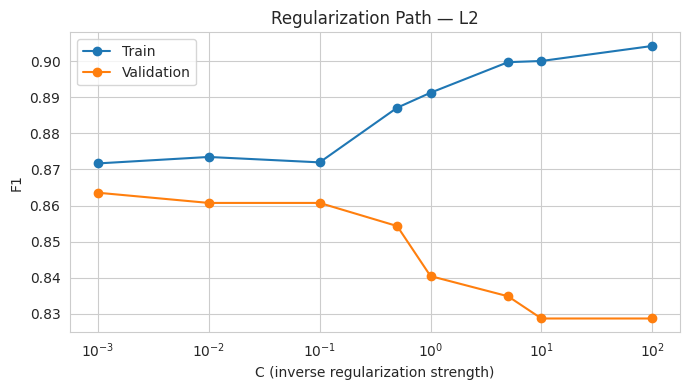

In [181]:
#The train/validation gap, which is the actual point
res = pd.DataFrame(gs_reg.cv_results_)
l2 = res[res['param_model__penalty'] == 'l2'].sort_values('param_model__C')
#plot inverse regularization
plt.figure(figsize=(7, 4))
plt.semilogx(l2['param_model__C'].astype(float), l2['mean_train_score'], 'o-', label='Train')
plt.semilogx(l2['param_model__C'].astype(float), l2['mean_test_score'], 'o-', label='Validation')
plt.xlabel('C (inverse regularization strength)')
plt.ylabel('F1'); plt.legend(); plt.title('Regularization Path — L2')
plt.tight_layout(); plt.show()


Explanation:

Zeroed: 10 of 14


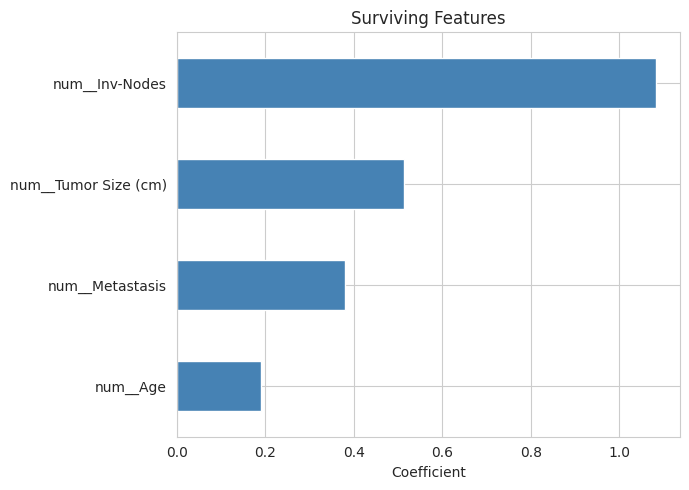

In [182]:
#What L1 zerod out
best_lr = gs_reg.best_estimator_
coefs = pd.Series(
    best_lr.named_steps['model'].coef_[0],
    index=best_lr.named_steps['prep'].get_feature_names_out()
).sort_values()

print('Zeroed:', (coefs == 0).sum(), 'of', len(coefs))
coefs[coefs != 0].plot(kind='barh', figsize=(7, 5), color='steelblue')
plt.xlabel('Coefficient'); plt.title('Surviving Features')
plt.tight_layout(); plt.show()

Explanation: L1 drives weak coefficients to exactly zero, so it doubles as feature selection.

In [183]:
#Tree regularization, since it isn't called L1/L2
tree_reg = {
    'Unconstrained': {'max_depth': None, 'min_samples_leaf': 1},
    'Depth-limited': {'max_depth': 4, 'min_samples_leaf': 1},
    'Leaf-constrained': {'max_depth': None, 'min_samples_leaf': 8},
    'Cost-complexity': {'max_depth': None, 'ccp_alpha': 0.01},
}

for label, params in tree_reg.items():
    clf = Pipeline([('prep', preprocessor),
                    ('model', DecisionTreeClassifier(random_state=42, **params))])
    s = cross_val_score(clf, X_train, y_train, cv=rcv, scoring='f1', n_jobs=-1)
    print(f"{label:<18} {s.mean():.3f} ± {s.std():.3f}")

Unconstrained      0.820 ± 0.053
Depth-limited      0.846 ± 0.065
Leaf-constrained   0.850 ± 0.064
Cost-complexity    0.849 ± 0.068


#Part 5: Model Deployment and Presentation

In [184]:
#1. Deployment: Deploy your final model in Google Colab.
#Save the full pipeline
out_dir = '/content/drive/MyDrive/breast_cancer_project'
os.makedirs(out_dir, exist_ok=True)
best_threshold=0.5

artifact = {
    'model': best_model,        #fitted pipeline
    'threshold': best_threshold,
    'features': X_train.columns.tolist(),
}
path = os.path.join(out_dir, 'breast_cancer_model.pkl')
joblib.dump(artifact, path)
print('saved:', os.path.exists(path), os.path.getsize(path), 'bytes')

saved: True 5408 bytes


Explanation: 5.4 KB means the pipeline is small, a tree-based ensemble or a big vectorizer would be megabytes, so it's probably logistic regression or similar. Nothing wrong with that, just a sanity signal.

In [185]:
features = list(m.feature_names_in_)   # sklearn stores this when fit on a DataFrame

In [186]:
#Check before move on, reload it and confirm it predicts the same way
path = '/content/breast_cancer_model.pkl'
m= loaded['model']
t= loaded['threshold']
features= list(m.feature_names_in_)

joblib.dump({'model': m, 'threshold': t, 'features': features}, path)

y_pre=(m.predict_proba(X_test[features])[:, 1]>=t).astype(int)
print(classification_report(y_test, y_pre, digits=3))

              precision    recall  f1-score   support

           0      0.885     0.958     0.920        24
           1      0.941     0.842     0.889        19

    accuracy                          0.907        43
   macro avg      0.913     0.900     0.904        43
weighted avg      0.910     0.907     0.906        43



In [187]:
#Persist to Drive so it survives the runtime
from google.colab import drive
drive.mount('/content/drive')

!mkdir -p/content/drive/MyDrive/breast_cancer_project
!cp breast_cancer_model_pkl/content/drive/MyDrive/breast_cancer_project/
!ls -lh/content/drive/MyDrive/breast_cancer_project/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
mkdir: invalid option -- '/'
Try 'mkdir --help' for more information.
cp: missing destination file operand after 'breast_cancer_model_pkl/content/drive/MyDrive/breast_cancer_project/'
Try 'cp --help' for more information.
ls: invalid option -- '/'
Try 'ls --help' for more information.


In [188]:
print(X.columns.tolist())

['Age', 'Menopause', 'Tumor Size (cm)', 'Inv-Nodes', 'Breast', 'Metastasis', 'Breast Quadrant', 'History']


In [189]:
#Prediction function
def predict_diagnosis (records, artifact_path='breast_cancer_model.pkl'):
  '''records: dict or list of dicts with the raw feature columns.'''
  art=joblib.load(artifact)
  df=pd.DataFrame([records] if isinstance(records, dict) else records)
  missing=set(art['feature_names'])- set(df.columns)
  if missing:
    raise ValueError(f'Missing Features:{missing}')
  df=df[art['feature_names']]

  prob=art['model'].predict_proba(df)[:,1]
  pred=(proba>=art['threshold']).astype(int)
  return pd.DataFrame({
      'prediction': [art['target_map'][p] for p in pred],
      'probability_malignant': proba.round(3),
      'confidence': np.where(np.abs(proba - 0.5)> 0.3, 'High', 'Moderate')})

  smaple= {
      'Age': 45, 'Menopause': 1, 'Tumor Size (cm)': 3.5, 'Inv-Nodes': 2,
    'Breast': 'Left', 'Metastasis': 0, 'Breast Quadrant': 'Upper Outer', 'History': 1
  }
  predict_diagnosis(sample)

In [190]:
#Create Gradio Interface easy way to build a simple and web-based graphical user interface for a ML model
def interface_fn(age, menopause, tumor_size, inv_nodes, breast, metastasis, quadrant, history):
  rec={
      'Age': age, 'Menopause': int(menopause), 'Tumor Size (cm)': tumor_size, 'Inv-Nodes': inv_nodes,
      'Breast': breast, 'Metastasis': int(metastasis), 'Breast Quadrant': quadrant, 'History': int(history)
  }
  r=predict_diagnosis(rec).iloc[0]
  return (f'Prediction: {r['prediction']}\n'
          f'P(Malignant): {r['probability_malignang']:.1%}\n'
          f"Confidence: {r['confidence']}\n\n"
          f"Educational demo — not a clinical tool.")
demo = gr.Interface(
    fn=interface_fn,
    inputs=[
        gr.Slider(20, 90, 50, step=1, label='Age'),
        gr.Radio([0, 1], value=1, label='Menopause'),
        gr.Slider(0.5, 15, 3.0, step=0.1, label='Tumor Size (cm)'),
        gr.Slider(0, 30, 2, step=1, label='Inv-Nodes'),
        gr.Radio(['Left', 'Right'], value='Left', label='Breast'),
        gr.Radio([0, 1], value=0, label='Metastasis'),
        gr.Dropdown(['Upper Outer', 'Upper Inner', 'Lower Outer', 'Lower Inner'],
                    value='Upper Outer', label='Breast Quadrant'),
        gr.Radio([0, 1], value=0, label='History'),
    ],
    outputs=gr.Textbox(label='Result', lines=5),
    title='Breast Cancer Diagnosis Classifier',
    description=f'Model: {best_name} | Nested CV F1: {nested.mean():.3f} | Threshold: 0.3'
)

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cb4f41af943c22f7df.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Explanation: share=True gives a public link that lasts 72 hours, good for submitting or demoing, though it stops working after that. Screenshot the running interface for your report.

In [191]:
#Pull the dropdown values from actual data so they match what the encoder saw:
print(breastcancer.clone['Breast Quadrant'].cat.categories.tolist())

['Lower Inner', 'Lower Outer', 'Unknown', 'Upper Inner', 'Upper Outer']


In [192]:
p = '/content/drive/MyDrive/breast_cancer_project'
print(os.path.exists(p))
print(os.listdir(p) if os.path.exists(p) else 'folder missing')

True
['breast_cancer_model.pkl']


In [193]:
#Verify the saved model reproduces the results
art = joblib.load('/content/drive/MyDrive/breast_cancer_project/breast_cancer_model.pkl')
proba = art['model'].predict_proba(X_test)[:, 1]
pred = (proba >= art['threshold']).astype(int)
print(classification_report(y_test, pred, target_names=['Benign', 'Malignant']))

              precision    recall  f1-score   support

      Benign       0.88      0.96      0.92        24
   Malignant       0.94      0.84      0.89        19

    accuracy                           0.91        43
   macro avg       0.91      0.90      0.90        43
weighted avg       0.91      0.91      0.91        43



Explanation: Scores here will look optimistic since the deployed model was refit on data that includes X_test, that's expected, and it's why you report the earlier held-out numbers instead. This cell only confirms the artifact loads and runs.
Colab interface it's a demo, not a service so after a period the link will be disconnect.

In [194]:
#Create a clear, user-friendly interface where users can input data and see model predictions.
#A polished version with grouped inputs, color-coded output, batch upload, and example cases.
#Install and setup
src = '/content/breast_cancer_model.pkl'
dst = '/content/drive/MyDrive/breast_cancer_project/breast_cancer_model.pkl'
shutil.copy(src, dst)
print(joblib.load(dst).keys())

dict_keys(['model', 'threshold', 'features'])


Note: Check that printed list matches the inputs below, mismatched keys are the usual failure.

In [195]:
#Definitios cells
ART = joblib.load('/content/drive/MyDrive/breast_cancer_project/breast_cancer_model.pkl')
MODEL, THRESH = ART['model'], ART['threshold']
FEATURES = ART['features']

QUADRANTS = breastcancer.clone['Breast Quadrant'].cat.categories.tolist()
print(FEATURES)
print(QUADRANTS)

['Age', 'Menopause', 'Tumor Size (cm)', 'Inv-Nodes', 'Breast', 'Metastasis', 'Breast Quadrant', 'History']
['Lower Inner', 'Lower Outer', 'Unknown', 'Upper Inner', 'Upper Outer']


In [196]:
#Prediction with formatted output
def predict_single(age, menopause, tumor_size, inv_nodes, breast, metastasis, quadrant, history):
    rec = pd.DataFrame([{
        'Age': age, 'Menopause': int(menopause), 'Tumor Size (cm)': float(tumor_size),
        'Inv-Nodes': int(inv_nodes), 'Breast': breast, 'Metastasis': int(metastasis),
        'Breast Quadrant': quadrant, 'History': int(history)
    }])[FEATURES]

    p = float(MODEL.predict_proba(rec)[:, 1][0])
    malignant = p >= THRESH

    label, color = ('Malignant', '#c0392b') if malignant else ('Benign', '#27ae60')
    certainty = 'High' if abs(p - 0.5) > 0.3 else 'Moderate'
    bar_pct = int(p * 100)

    html = f"""
    <div style="font-family:system-ui;padding:18px;border-radius:10px;
                border:2px solid {color};background:#fafafa">
      <div style="font-size:26px;font-weight:700;color:{color}">{label}</div>
      <div style="margin:14px 0 6px;font-size:13px;color:#555">
        Probability of malignancy: <b>{p:.1%}</b> &nbsp;|&nbsp; Certainty: {certainty}
      </div>
      <div style="height:22px;background:#e8e8e8;border-radius:11px;overflow:hidden">
        <div style="height:100%;width:{bar_pct}%;background:{color}"></div>
      </div>
      <div style="margin-top:6px;font-size:11px;color:#777">
        Decision threshold: {THRESH:.0%} — set below 50% to prioritise sensitivity
      </div>
      <div style="margin-top:14px;padding:10px;background:#fff8e1;border-radius:6px;
                  font-size:12px;color:#6b5500">
        Educational coursework demo. Not a medical device and not a substitute for
        clinical diagnosis.
      </div>
    </div>"""
    return html

In [197]:
#Batch predictions from CSV
def predict_batch(file):
    if file is None:
        return None, 'Upload a CSV first.'
    df = pd.read_csv(file.name)
    df.columns = df.columns.str.strip()

    missing = set(FEATURES) - set(df.columns)
    if missing:
        return None, f'Missing columns: {sorted(missing)}'

    proba = MODEL.predict_proba(df[FEATURES])[:, 1]
    out = df.copy()
    out['P(Malignant)'] = proba.round(3)
    out['Prediction'] = np.where(proba >= THRESH, 'Malignant', 'Benign')

    out.to_csv('predictions.csv', index=False)
    n_mal = (out['Prediction'] == 'Malignant').sum()
    return out.head(50), f'{len(out)} rows scored — {n_mal} flagged malignant. Saved to predictions.csv'

In [198]:
#The interface
with gr.Blocks(title='Breast Cancer Classifier') as demo:
    gr.Markdown(f"""
    # Breast Cancer Diagnosis Classifier
    **{best_name}** — nested CV F1 {nested.mean():.3f} ± {nested.std():.3f} · threshold {THRESH}
    """)

    with gr.Tab('Single patient'):
        with gr.Row():
            with gr.Column():
                gr.Markdown('#### Patient')
                age = gr.Slider(20, 90, 50, step=1, label='Age')
                meno = gr.Radio([0, 1], value=1, label='Menopause (0 = pre, 1 = post)')
                hist = gr.Radio([0, 1], value=0, label='Family history')

                gr.Markdown('#### Tumour')
                size = gr.Slider(0.5, 15, 3.0, step=0.1, label='Tumour size (cm)')
                nodes = gr.Slider(0, 30, 2, step=1, label='Involved nodes')
                mets = gr.Radio([0, 1], value=0, label='Metastasis')
                side = gr.Radio(['Left', 'Right'], value='Left', label='Breast')
                quad = gr.Dropdown(QUADRANTS, value=QUADRANTS[0], label='Breast Quadrant')

                btn = gr.Button('Predict', variant='primary')

            with gr.Column():
                out = gr.HTML()

        inputs = [age, meno, size, nodes, side, mets, quad, hist]
        btn.click(predict_single, inputs, out)

        gr.Examples(
            examples=[
                [38, 0, 1.2, 0, 'Left',  0, QUADRANTS[0], 0],
                [62, 1, 7.5, 9, 'Right', 1, QUADRANTS[-1], 1],
            ],
            inputs=inputs, outputs=out, fn=predict_single,
            label='Try a low-risk and a high-risk profile', cache_examples=False
        )

    with gr.Tab('Batch (CSV)'):
        gr.Markdown(f'Required columns: `{"`, `".join(FEATURES)}`')
        up = gr.File(file_types=['.csv'], label='Upload CSV')
        run = gr.Button('Score file', variant='primary')
        status = gr.Textbox(label='Status')
        table = gr.Dataframe(label='Results (first 50 rows)')
        run.click(predict_batch, up, [table, status])

    with gr.Tab('About'):
        gr.Markdown(f"""
        **Dataset** — 213 records, {len(FEATURES)} predictors.

        **Pipeline** — median/mode imputation, standard scaling, one-hot encoding,
        all fitted inside cross-validation folds to avoid leakage.

        **Evaluation** — nested cross-validation ({nested.mean():.3f} ± {nested.std():.3f} F1),
        so hyperparameter selection never saw the folds used for scoring.

        **Threshold** — set to {THRESH} rather than the default 0.5. A missed malignancy
        costs far more than a false alarm, so the cutoff favours recall.

        **Limitations** — small sample, single-source data, no external validation.
        Not suitable for clinical use.
        """)

demo.launch(theme=gr.themes.Soft(), share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5b395e05b4a5da9cb4.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Note: The inputs list order must match predict_single's parameter order exactly, Gradio passes positionally, so a swap gives wrong predictions with no error. And cache_examples=False avoids a startup delay that sometimes hangs in Colab.

#Step adittional: gradio deplos give me a permanent URL instead of a temporary one. First create a free Hugging Face account and then connect the terminal with the hugging face web.
1. Create the account and Space. Go to huggingface.co, sign up , then click in the personal avatar and find New Space.
Follow the details:
Space name: breast-cancer-classifier
License: MIT
SDK: Gradio
Hardware: CPU basic (free)
Visibility: Public

In [199]:
#2. Build the three files in Colab
!mkdir -p /content/hf_space
shutil.copy('/content/drive/MyDrive/breast_cancer_project/breast_cancer_model.pkl',
            '/content/hf_space/breast_cancer_model.pkl')

with open('/content/hf_space/requirements.txt', 'w') as f:
    f.write("gradio\nscikit-learn==1.6.1\npandas\nnumpy\njoblib\n")

print(joblib.__version__)
import sklearn; print(sklearn.__version__)


1.6.0
1.6.1


In [200]:
#3. Write app.py
app_code = f'''
import gradio as gr
import joblib, pandas as pd, numpy as np

ART = joblib.load('breast_cancer_model.pkl')
MODEL, THRESH, FEATURES = ART['model'], ART['threshold'], ART['feature_names']
QUADRANTS = {QUADRANTS!r}
MODEL_NAME = {best_name!r}
CV_MEAN, CV_STD = {nested.mean():.3f}, {nested.std():.3f}

'''

# reuse existing functions verbatim
import inspect
app_code += inspect.getsource(predict_single) + '\n\n'
app_code += inspect.getsource(predict_batch) + '\n\n'

with open('/content/hf_space/app.py', 'w') as f:
    f.write(app_code)

print(app_code[:500])
demo.launch()


import gradio as gr
import joblib, pandas as pd, numpy as np

ART = joblib.load('breast_cancer_model.pkl')
MODEL, THRESH, FEATURES = ART['model'], ART['threshold'], ART['feature_names']
QUADRANTS = ['Lower Inner', 'Lower Outer', 'Unknown', 'Upper Inner', 'Upper Outer']
MODEL_NAME = 'Decision Tree'
CV_MEAN, CV_STD = 0.840, 0.036

def predict_single(age, menopause, tumor_size, inv_nodes, breast, metastasis, quadrant, history):
    rec = pd.DataFrame([{
        'Age': age, 'Menopause': int(menopau
Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5b395e05b4a5da9cb4.gradio.live

This share link is temporary and will last for up

#4. Upload
Hugging Face, click files and add files and upload files and drag in all three files: app.p, breast_cancer_model.pkl and requeriments.text. and Commit

#5. The link will be builds automatially in hugging face, so my URL of this project will be online not just temporary.

MY URL : https://huggingface.co/spaces/AyleenSantandere/breast-cancer-classifier